Embeddings : (2078, 32)
Labels     : (2078, 5)
k= 2  silhouette=0.3723
k= 3  silhouette=0.3844
k= 4  silhouette=0.3174
k= 5  silhouette=0.3003
k= 6  silhouette=0.2473
k= 7  silhouette=0.2324
k= 8  silhouette=0.1997
k= 9  silhouette=0.1842
k=10  silhouette=0.1766

Best k by silhouette score: 3


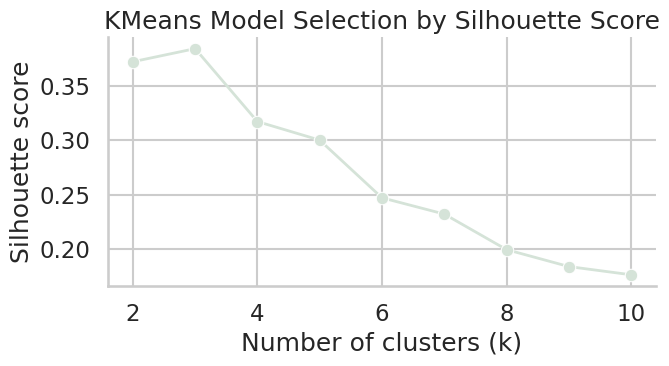

Cluster membership matrix shape: (2078, 3)


,cluster_0,cluster_1,cluster_2
id,,,
0,0,1,0
1,0,1,0
2,1,0,0
3,0,1,0
4,0,1,0



Cluster sizes:


,cluster,size
0,0,375
1,1,1026
2,2,677


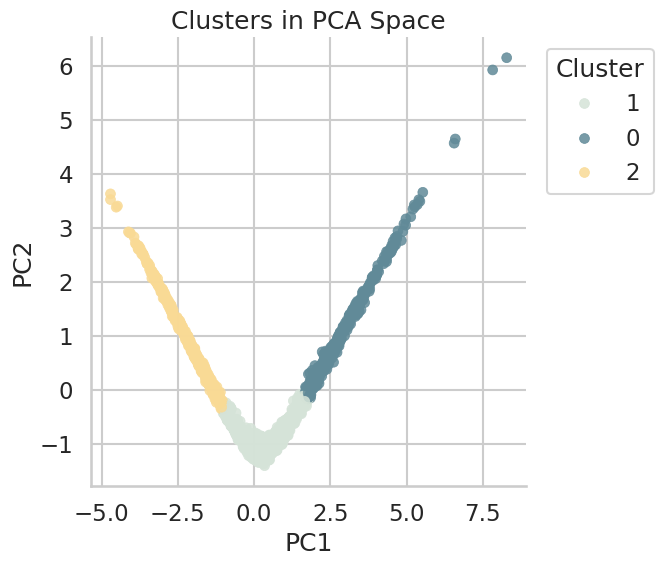

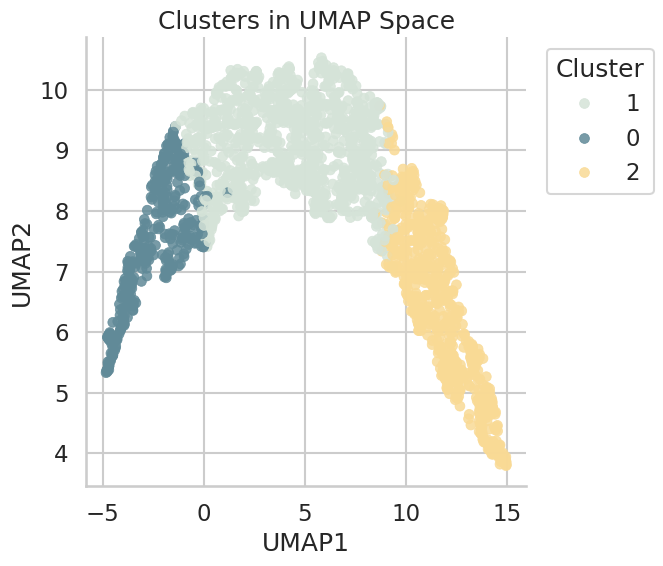


Per-cluster label proportions:


,cluster_size,CAD,CKD,DMT2,Healthy,OST
cluster,,,,,,
0,375,0.701333,0.488000,0.498667,0.034667,0.149333
1,1026,0.226121,0.275828,0.209552,0.312865,0.231969
2,677,0.026588,0.047267,0.023634,0.775480,0.159527


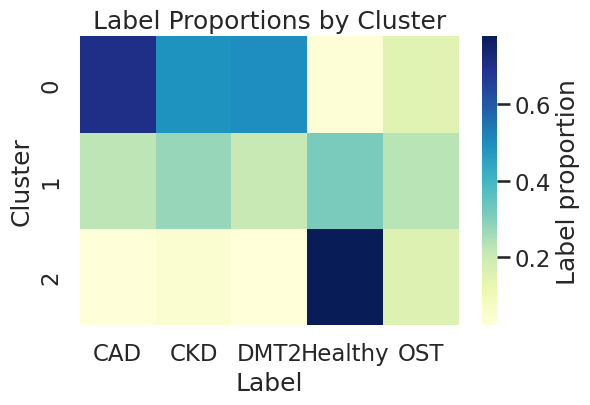


Top enriched labels per cluster:

Cluster 0


,label,prop_in_cluster,prop_out_cluster,fold_enrichment,odds_ratio,p_value,q_value,significant
0,CAD,0.701,0.147,4.78,13.65,1.799e-98,1.349e-97,True
2,DMT2,0.499,0.136,3.68,6.34,1.792e-48,8.959e-48,True
1,CKD,0.488,0.185,2.64,4.20,6.922e-32,2.596e-31,True
4,OST,0.149,0.203,0.74,0.69,9.941e-01,1.000e+00,False
3,Healthy,0.035,0.497,0.07,0.04,1.000e+00,1.000e+00,False



Cluster 1


,label,prop_in_cluster,prop_out_cluster,fold_enrichment,odds_ratio,p_value,q_value,significant
9,OST,0.232,0.156,1.49,1.64,7.063e-06,2.119e-05,True
6,CKD,0.276,0.204,1.35,1.48,8.256e-05,2.064e-04,True
7,DMT2,0.210,0.193,1.09,1.11,1.872e-01,4.011e-01,False
5,CAD,0.226,0.267,0.85,0.80,9.867e-01,1.000e+00,False
8,Healthy,0.313,0.511,0.61,0.44,1.000e+00,1.000e+00,False



Cluster 2


,label,prop_in_cluster,prop_out_cluster,fold_enrichment,odds_ratio,p_value,q_value,significant
13,Healthy,0.775,0.238,3.25,11.03,3.867e-123,5.800e-122,True
14,OST,0.160,0.210,0.76,0.71,9.976e-01,1.000e+00,False
11,CKD,0.047,0.333,0.14,0.10,1.000e+00,1.000e+00,False
12,DMT2,0.024,0.287,0.08,0.06,1.000e+00,1.000e+00,False
10,CAD,0.027,0.353,0.08,0.05,1.000e+00,1.000e+00,False


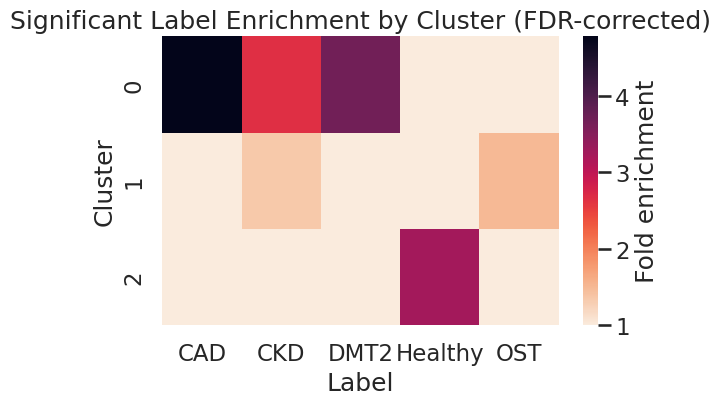


Cluster summary:


,size,fraction_of_dataset,n_significant_enriched_labels,top_enriched_labels
cluster,,,,
0,375,0.180,3,"CAD, DMT2, CKD"
1,1026,0.494,2,"OST, CKD"
2,677,0.326,1,Healthy


In [5]:
# ============================================================
# Clustering + Label Enrichment on GNN Embeddings
# ============================================================
# Loads pre-computed GNN embeddings and multilabel targets, then:
#   1. Standardizes embeddings
#   2. Chooses number of clusters by silhouette score
#   3. Runs KMeans clustering
#   4. Visualizes clusters in PCA / UMAP space
#   5. Computes per-cluster label proportions
#   6. Tests label enrichment in each cluster
# ============================================================

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import umap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

from palettable.wesanderson import Darjeeling2_5

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH = "/work/gr-fe/bryan/MOGSage/results/Final/mogsage_gnn_embeddings_0.2.pkl"
RANDOM_STATE = 42
K_RANGE = range(2, 11)      # candidate cluster counts
PCA_DIM = 30                # reduce before KMeans if embeddings are high-dim
TOP_N_ENRICHED = 10         # show top enriched labels per cluster
FDR_ALPHA = 0.05

# ── Plot style ────────────────────────────────────────────────────────────────
PALETTE = Darjeeling2_5.mpl_colors
sns.set_theme(style="whitegrid", context="talk", palette=PALETTE)

# ── 1. Load embeddings + labels ──────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H = blob["embeddings"]              # (N, d)
y = blob["y"].astype(int)           # (N, C), multi-hot

train_idx = blob.get("train_idx")
val_idx   = blob.get("val_idx")
test_idx  = blob.get("test_idx")

N, D = H.shape
C = y.shape[1]

print(f"Embeddings : {H.shape}")
print(f"Labels     : {y.shape}")

# Optional label names if you have them; otherwise generic names
label_names = blob.get("label_names", [f"label_{j}" for j in range(C)])

# ── 3. Choose k using silhouette score ───────────────────────────────────────
k_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    cluster_labels = km.fit_predict(H)
    sil = silhouette_score(H, cluster_labels)
    k_scores.append({"k": k, "silhouette": sil})
    print(f"k={k:2d}  silhouette={sil:.4f}")

df_k = pd.DataFrame(k_scores)
best_k = 3
print(f"\nBest k by silhouette score: {best_k}")

# Plot silhouette vs k
plt.figure(figsize=(7, 4))
sns.lineplot(data=df_k, x="k", y="silhouette", marker="o", linewidth=2)
plt.title("KMeans Model Selection by Silhouette Score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
sns.despine()
plt.tight_layout()
plt.show()

# ── 4. Final clustering ──────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=int(best_k), n_init=20, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(H)

# Binary membership matrix: ids x clusters
unique_clusters = np.sort(np.unique(clusters))
n_clusters = len(unique_clusters)

cluster_membership = np.zeros((N, n_clusters), dtype=np.int8)
cluster_membership[np.arange(N), clusters] = 1

df_cluster_membership = pd.DataFrame(
    cluster_membership,
    index=np.arange(N),
    columns=[f"cluster_{c}" for c in unique_clusters]
)
df_cluster_membership.index.name = "id"

print("Cluster membership matrix shape:", cluster_membership.shape)
display(df_cluster_membership.head())

np.save("/work/gr-fe/bryan/MOGSage/results/Final/mogsage_cluster_membership.npy", cluster_membership)

df_meta = pd.DataFrame({
    "cluster": clusters
})

cluster_sizes = (
    df_meta["cluster"]
    .value_counts()
    .sort_index()
    .rename("size")
    .reset_index()
    .rename(columns={"index": "cluster"})
)

print("\nCluster sizes:")
display(cluster_sizes)

# ── 5. 2D visualization (PCA + UMAP if available) ────────────────────────────
# PCA 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
H_pca2 = pca_2d.fit_transform(H)

df_plot_pca = pd.DataFrame({
    "PC1": H_pca2[:, 0],
    "PC2": H_pca2[:, 1],
    "cluster": clusters.astype(str)
})

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=PALETTE[:int(best_k)] if best_k <= len(PALETTE) else "tab10",
    s=50,
    alpha=0.85,
    edgecolor=None
)
plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

# UMAP 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE
)
H_umap = reducer.fit_transform(H)

df_plot_umap = pd.DataFrame({
    "UMAP1": H_umap[:, 0],
    "UMAP2": H_umap[:, 1],
    "cluster": clusters.astype(str)
})

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot_umap,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette=PALETTE[:int(best_k)] if best_k <= len(PALETTE) else "tab10",
    s=50,
    alpha=0.85,
    edgecolor=None
)
plt.title("Clusters in UMAP Space")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig('./../../results/Figures/GNNEmbeddings.svg', format="svg", bbox_inches="tight")
plt.show()

# ── 6. Per-cluster label proportions ─────────────────────────────────────────
# global proportion per label
global_prop = y.mean(axis=0)

cluster_prop_rows = []
for c in sorted(np.unique(clusters)):
    idx = np.where(clusters == c)[0]
    prop = y[idx].mean(axis=0)

    row = {"cluster": c, "cluster_size": len(idx)}
    for j, name in enumerate(label_names):
        row[name] = prop[j]
    cluster_prop_rows.append(row)

df_cluster_props = pd.DataFrame(cluster_prop_rows).set_index("cluster")

print("\nPer-cluster label proportions:")
display(df_cluster_props.iloc[:, :min(10, df_cluster_props.shape[1])])

# Heatmap of proportions
heatmap_df = df_cluster_props.drop(columns=["cluster_size"], errors="ignore")
plt.figure(figsize=(min(18, 0.45 * heatmap_df.shape[1] + 4), 0.8 * heatmap_df.shape[0] + 2))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=False,
    cbar_kws={"label": "Label proportion"}
)
plt.title("Label Proportions by Cluster")
plt.xlabel("Label")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# ── 7. Enrichment testing per cluster x label ────────────────────────────────
# For each cluster c and label j, test whether label j is enriched in cluster c
# versus the rest of the dataset using one-sided Fisher exact test.
enrichment_rows = []

for c in sorted(np.unique(clusters)):
    in_cluster = (clusters == c)
    out_cluster = ~in_cluster

    n_in = in_cluster.sum()
    n_out = out_cluster.sum()

    for j, name in enumerate(label_names):
        label_in = y[in_cluster, j].sum()
        label_out = y[out_cluster, j].sum()

        nonlabel_in = n_in - label_in
        nonlabel_out = n_out - label_out

        table = np.array([
            [label_in, nonlabel_in],
            [label_out, nonlabel_out]
        ])

        # One-sided test for enrichment (greater odds inside cluster)
        odds_ratio, pval = fisher_exact(table, alternative="greater")

        prop_in = label_in / n_in if n_in > 0 else np.nan
        prop_out = label_out / n_out if n_out > 0 else np.nan
        fold_enrichment = (prop_in + 1e-12) / (prop_out + 1e-12)

        enrichment_rows.append({
            "cluster": c,
            "label": name,
            "n_in_cluster": n_in,
            "label_count_in_cluster": int(label_in),
            "label_count_out_cluster": int(label_out),
            "prop_in_cluster": prop_in,
            "prop_out_cluster": prop_out,
            "global_prop": global_prop[j],
            "fold_enrichment": fold_enrichment,
            "odds_ratio": odds_ratio,
            "p_value": pval,
        })

df_enrich = pd.DataFrame(enrichment_rows)

# FDR correction across all cluster-label tests
reject, qvals, _, _ = multipletests(df_enrich["p_value"].values, alpha=FDR_ALPHA, method="fdr_bh")
df_enrich["q_value"] = qvals
df_enrich["significant"] = reject

# Sort useful summary
df_enrich = df_enrich.sort_values(
    ["cluster", "q_value", "fold_enrichment"],
    ascending=[True, True, False]
)

print("\nTop enriched labels per cluster:")
for c in sorted(df_enrich["cluster"].unique()):
    print(f"\nCluster {c}")
    df_top = (
        df_enrich[df_enrich["cluster"] == c]
        .sort_values(["q_value", "fold_enrichment"], ascending=[True, False])
        .head(TOP_N_ENRICHED)
    )
    display(
        df_top[[
            "label",
            "prop_in_cluster",
            "prop_out_cluster",
            "fold_enrichment",
            "odds_ratio",
            "p_value",
            "q_value",
            "significant"
        ]]
        .style
        .format({
            "prop_in_cluster": "{:.3f}",
            "prop_out_cluster": "{:.3f}",
            "fold_enrichment": "{:.2f}",
            "odds_ratio": "{:.2f}",
            "p_value": "{:.3e}",
            "q_value": "{:.3e}",
        })
    )

# ── 8. Visual summary of significant enrichments ─────────────────────────────
# Keep only significant enrichments and show fold enrichment as a heatmap
df_sig = df_enrich[df_enrich["significant"]].copy()

if len(df_sig) > 0:
    enrich_mat = df_sig.pivot(index="cluster", columns="label", values="fold_enrichment").fillna(1.0)

    plt.figure(figsize=(min(18, 0.45 * enrich_mat.shape[1] + 4), 0.8 * enrich_mat.shape[0] + 2))
    sns.heatmap(
        enrich_mat,
        cmap="rocket_r",
        annot=False,
        cbar_kws={"label": "Fold enrichment"}
    )
    plt.title("Significant Label Enrichment by Cluster (FDR-corrected)")
    plt.xlabel("Label")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.savefig('./../../results/Figures/ClusterEnrichment.svg', format="svg", bbox_inches="tight")
    plt.show()
else:
    print("\nNo significant enrichments found at the chosen FDR threshold.")

# ── 9. Cluster-wise summary table ────────────────────────────────────────────
summary_rows = []
for c in sorted(np.unique(clusters)):
    idx = np.where(clusters == c)[0]
    size = len(idx)

    sig_labels = (
        df_enrich[(df_enrich["cluster"] == c) & (df_enrich["significant"])]
        .sort_values(["q_value", "fold_enrichment"], ascending=[True, False])
    )

    top_labels = sig_labels["label"].head(5).tolist()
    summary_rows.append({
        "cluster": c,
        "size": size,
        "fraction_of_dataset": size / N,
        "n_significant_enriched_labels": sig_labels.shape[0],
        "top_enriched_labels": ", ".join(top_labels) if top_labels else "-"
    })

df_cluster_summary = pd.DataFrame(summary_rows).set_index("cluster")

print("\nCluster summary:")
display(
    df_cluster_summary.style.format({
        "fraction_of_dataset": "{:.3f}"
    })
)